‎ 


# 0. Setup

In [1]:
from Requirements import *

from collections import Counter
from sklearn.model_selection import train_test_split

In [2]:
from tensorflow.keras.datasets import mnist

2025-10-13 13:39:36.500752: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-13 13:39:36.516280: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-13 13:39:36.546273: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-13 13:39:36.580776: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-13 13:39:36.591058: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-13 13:39:36.631456: I tensorflow/core/platform/cpu_feature_gu

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


In [ ]:
number_samples = 100

RUN_AGAIN = True

if RUN_AGAIN : 
    
    x_train_new, _, y_train_new, _ = train_test_split(x_train, y_train, train_size = number_samples, random_state = 42, stratify = y_train)

    x_test_new, _, y_test_new, _ = train_test_split(x_test, y_test, train_size = int(number_samples/10), random_state = 42, stratify = y_test)

    with open("1. Data/4. Pickles/1. Quantum Machine Learning/qknn_train_test_2500.pkl", "wb") as f:

        pickle.dump((x_train_new, y_train_new, x_test_new, y_test_new), f)

else :
    
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/qknn_train_test_2500.pkl", "rb") as f:

        x_train_new, y_train_new, x_test_new, y_test_new = pickle.load(f)

train_counts = Counter(y_train_new)
test_counts = Counter(y_test_new)

headers = sorted(train_counts.keys())
train_row = ["Train",] + [train_counts[d] for d in headers]
test_row = ["Test",] + [test_counts[d] for d in headers]
train_percentage_row = ["Train %",] + [f"{(train_counts[d]/number_samples)*100:.1f}%" for d in headers]
test_percentage_row = ["Test %",] + [f"{(test_counts[d]/(number_samples/10))*100:.1f}%" for d in headers]

print(f"\nDistribution of digits in the training set (n={number_samples}):\n")
print(tabulate([train_row, train_percentage_row], headers=["Set"] + headers))

print("\n" + "-"*50 + "\n")

print(f"\nDistribution of digits in the test set (n={int(number_samples/10)}):\n")
print(tabulate([test_row, test_percentage_row], headers=["Set"] + headers))



Distribution of digits in the training set (n=100):

Set      0      1      2      3      4      5     6      7      8      9
-------  -----  -----  -----  -----  -----  ----  -----  -----  -----  -----
Train    10     11     10     10     10     9     10     10     10     10
Train %  10.0%  11.0%  10.0%  10.0%  10.0%  9.0%  10.0%  10.0%  10.0%  10.0%

--------------------------------------------------


Distribution of digits in the test set (n=10):

Set     0      1      2      3      4      5      6      7      8      9
------  -----  -----  -----  -----  -----  -----  -----  -----  -----  -----
Test    1      1      1      1      1      1      1      1      1      1
Test %  10.0%  10.0%  10.0%  10.0%  10.0%  10.0%  10.0%  10.0%  10.0%  10.0%


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:

x_train_flat = x_train_new.reshape(x_train_new.shape[0], -1)
x_test_flat = x_test_new.reshape(x_test_new.shape[0], -1)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

In [8]:
pca_components = 16

pca = PCA(n_components = pca_components)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Shape of PCA-transformed x_train:", x_train_pca.shape)
print("Shape of PCA-transformed x_test:", x_test_pca.shape)

Shape of PCA-transformed x_train: (100, 16)
Shape of PCA-transformed x_test: (10, 16)


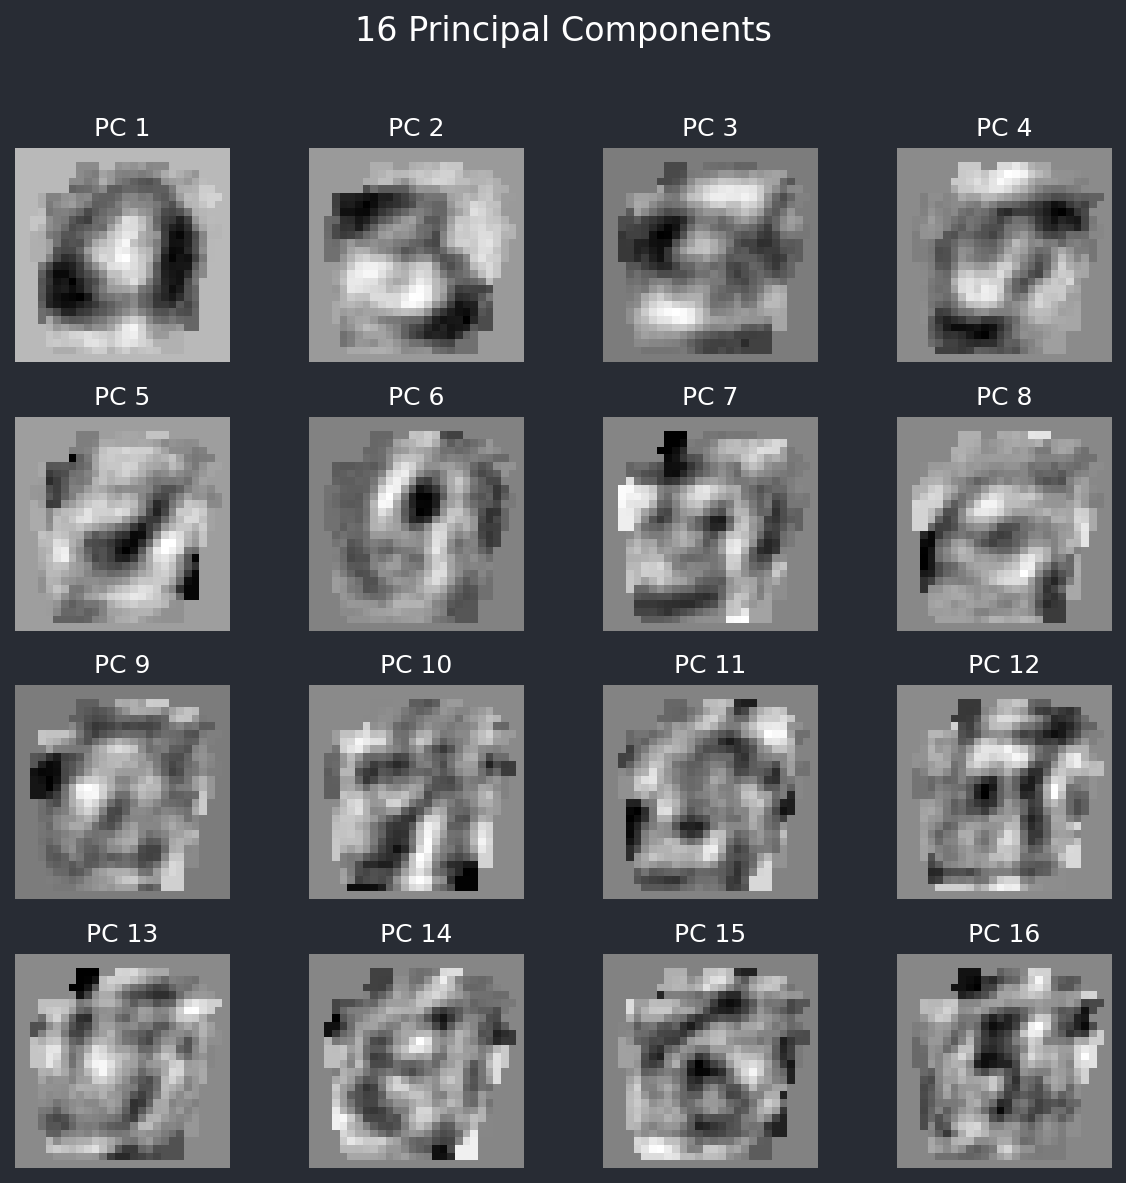

In [9]:
from matplotlib.pyplot import savefig


fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    
    ax.imshow(pca.components_[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"PC {i+1}")
    ax.axis('off')
    
plt.suptitle(f"{pca_components} Principal Components", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


‎ 

# 1. Quantum Loop

In [10]:
from qiskit_ibm_runtime import SamplerV2, Batch

In [11]:
service = QiskitRuntimeService()

management.get:WARNING:2025-10-13 13:39:39,635: Loading default saved account


In [12]:
backends = service.backends()

for b in backends:
    print(b.name)

ibm_brisbane
ibm_torino


In [13]:
backend = service.least_busy(
    operational=True,
    simulator=False
)

print(f"Selected backend: {backend.name}")
print(f"Pending jobs: {backend.status().pending_jobs}")

Selected backend: ibm_torino
Pending jobs: 694


In [14]:
max_circuits = backend.configuration().max_experiments  
max_executions = 10_000_000
shots = 1024
max_by_exec = max_executions // shots 

actual_max = min(max_circuits, max_by_exec) 
print(f"Max circuits per job: {actual_max}")

Max circuits per job: 300


In [15]:
def build_swap_test_circuit(vec_alpha, vec_vj):

    num_qubits_per_state = int(np.log2(len(vec_alpha)))
    qc = QuantumCircuit(1 + 2 * num_qubits_per_state, 1)

    alpha_qubits = list(range(1, num_qubits_per_state + 1))
    vj_qubits = list(range(num_qubits_per_state + 1, 1 + 2 * num_qubits_per_state))
    ancilla = 0

    qc.initialize(vec_alpha, alpha_qubits)
    qc.initialize(vec_vj, vj_qubits)

    qc.h(ancilla)
    for i in range(num_qubits_per_state):
        qc.cswap(ancilla, alpha_qubits[i], vj_qubits[i])
    qc.h(ancilla)
    qc.measure(ancilla, 0)
    return qc

In [16]:
x_test_pca_norm = []
for vec in x_test_pca:
    norm = np.linalg.norm(vec)
    # Avoid division by zero
    normalized_vec = vec / norm if norm != 0 else vec 
    x_test_pca_norm.append(normalized_vec)
    
x_train_pca_norm = []
for vec in x_train_pca:
    norm = np.linalg.norm(vec)
    normalized_vec = vec / norm if norm != 0 else vec
    x_train_pca_norm.append(normalized_vec)

In [17]:
print(len(x_test_pca_norm), len(x_train_pca_norm))

10 100


In [33]:
all_tasks_with_qc = []

for i in range(len(x_test_pca_norm)):
    
    norm_test_vec = x_test_pca_norm[i]
    
    for j in range(len(x_train_pca_norm)):

        norm_train_vec = x_train_pca_norm[j]
        
        qc = build_swap_test_circuit(norm_test_vec, norm_train_vec)
        
        all_tasks_with_qc.append({
            'test_index': i,
            'test_label': y_test_new[i],
            'train_index': j,
            'train_label': y_train_new[j],
            'qc': qc  
        })

print(len(all_tasks_with_qc))
print(all_tasks_with_qc[100])

1000
{'test_index': 1, 'test_label': 1, 'train_index': 0, 'train_label': 9, 'qc': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7b2d683b0bf0>}


In [19]:
first_test_index = 0

subset = [t for t in all_tasks_with_qc if t['test_index'] == first_test_index][:100]

circuits = [t['qc'] for t in subset]

print(len(circuits))

100


In [20]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(
    optimization_level=3,  # or 1, 2, 3
    backend=backend
)

isa_circuits = pm.run(circuits)

In [ ]:
shots = 1024

RUN_ON_QPU = False

if RUN_ON_QPU:
    sampler = SamplerV2(mode=backend)
    job = sampler.run([isa_circuits[0]], shots=shots)


    job_id = job.job_id()

else:

    job_id = 'd3mhiuhfk6qs73e7vha0'
    
    
print(f"Job ID: {job_id}")

Job ID: d3mhiuhfk6qs73e7vha0


In [22]:
job = service.job(job_id)
result = job.result()

pub_result = result[0]  

counts = pub_result.data.c.get_counts()

print("Counts:", counts)

distance = counts.get('1', 0) / shots

print(f"Estimated distance: {distance}")


Counts: {'0': 535, '1': 489}
Estimated distance: 0.4775390625


In [23]:
usage = job.usage_estimation

print("Estimated runtime (seconds):", usage["quantum_seconds"])

Estimated runtime (seconds): None


In [ ]:
shots = 1024

RUN_ON_QPU = False

if RUN_ON_QPU:

    with Batch(backend=backend) as batch:
        
        sampler = SamplerV2(mode=batch) 
        job = sampler.run(isa_circuits, shots=shots)

    job_id_0 = job.job_id()

else:
    
    job_id_0 = 'd3mhm2g3qtks738ddej0' 
    
print(f"Job ID: {job_id_0}")

Job ID: d3mhm2g3qtks738ddej0


In [ ]:
job = service.job(job_id_0)

result = job.result()

distances = []
for pub_result in result:
    counts = pub_result.data.c.get_counts()
    prob_1 = counts.get('1', 0) / shots
    distances.append(prob_1)

print(f"Number of results: {len(distances)}")
print(f"First 5 distances: {distances[:5]}")

Number of results: 100
First 5 distances: [0.4912109375, 0.4892578125, 0.48828125, 0.380859375, 0.505859375]


In [27]:
print("Job status:", job.status())

Job status: DONE


In [34]:
circuits_batch_1 = [task['qc'] for task in all_tasks_with_qc[100:400]]
circuits_batch_2 = [task['qc'] for task in all_tasks_with_qc[400:700]]
circuits_batch_3 = [task['qc'] for task in all_tasks_with_qc[700:1000]]


print(f"Length of Batch 1: {len(circuits_batch_1)}")
print(f"Length of Batch 2: {len(circuits_batch_2)}")
print(f"Length of Batch 3: {len(circuits_batch_3)}")


Length of Batch 1: 300
Length of Batch 2: 300
Length of Batch 3: 300


In [35]:
isa_circuits_1 = pm.run(circuits_batch_1)
isa_circuits_2 = pm.run(circuits_batch_2)
isa_circuits_3 = pm.run(circuits_batch_3)

In [39]:
shots = 1024

RUN_ON_QPU = False

if RUN_ON_QPU:
    
    print("Batch 1")
    
    with Batch(backend=backend) as batch:
        
        sampler = SamplerV2(mode=batch)
        job1 = sampler.run(isa_circuits_1, shots=shots)
        
    job_id_1 = job1.job_id()

else:

    job_id_1 = 'd3mj3hpfk6qs73e815u0'
       

print(f"Batch 1 Job ID: {job_id_1}")

Batch 1 Job ID: d3mj3hpfk6qs73e815u0


In [ ]:
shots = 1024

RUN_ON_QPU = True

if RUN_ON_QPU:
    
    print("Batch 2")
    
    batch = Batch(backend=backend)
    
    sampler = SamplerV2(mode=batch)
    
    job2 = sampler.run(isa_circuits_2, shots=shots)
        
    job_id_2 = job2.job_id()

else:

    job_id_2 = 'd3mjn0g3qtks738dfhgg'
       

print(f"Batch 2 Job ID: {job_id_2}")

Batch 2
Batch 2 Job ID: d3mjn0g3qtks738dfhgg


In [ ]:
shots = 1024

RUN_ON_QPU = True

if RUN_ON_QPU:
    
    print("Batch 3")
    
    batch = Batch(backend=backend)
    
    sampler = SamplerV2(mode=batch)

    job3 = sampler.run(isa_circuits_3, shots=shots)
        
    job_id_3 = job3.job_id()

else:

    job_id_3 = 'd3mk45pfk6qs73e824k0'
       

print(f"Batch 3 Job ID: {job_id_3}")

Batch 3
Batch 3 Job ID: d3mk45pfk6qs73e824k0


In [44]:
job_id_0 = 'd3mhm2g3qtks738ddej0' 
job_id_1 = 'd3mj3hpfk6qs73e815u0'
job_id_2 = 'd3mjn0g3qtks738dfhgg'
job_id_3 = 'd3mk45pfk6qs73e824k0'

In [46]:
def get_distances_from_job(job_id, service, shots):
    
    job = service.job(job_id)
    result = job.result()
    distances = []
    
    for pub_result in result:
        
        counts = pub_result.data.c.get_counts()
        
        prob_1 = counts.get('1', 0) / shots
        distances.append(prob_1)
    
    return distances

In [ ]:
distance_0 = get_distances_from_job(job_id_3, service, shots)

print(len(distance_0))

300


In [ ]:
distances = [*chain.from_iterable(get_distances_from_job(jid, service, shots) for jid in [job_id_0, job_id_1, job_id_2, job_id_3])]

print(len(distances))

1000


In [57]:
for i, task in enumerate(all_tasks_with_qc):
    
    task['distance'] = distances[i]

In [59]:
# transform to dataframe

df_all_tasks_with_qc = pd.DataFrame(all_tasks_with_qc)

df_all_tasks_with_qc


,test_index,test_label,train_index,train_label,qc,distance
0,0,7,0,9,"((Instruction(name='initialize', num_qubits=4,...",0.491211
1,0,7,1,0,"((Instruction(name='initialize', num_qubits=4,...",0.489258
2,0,7,2,9,"((Instruction(name='initialize', num_qubits=4,...",0.488281
3,0,7,3,7,"((Instruction(name='initialize', num_qubits=4,...",0.380859
4,0,7,4,1,"((Instruction(name='initialize', num_qubits=4,...",0.505859
...,...,...,...,...,...,...
995,9,4,95,6,"((Instruction(name='initialize', num_qubits=4,...",0.435547
996,9,4,96,7,"((Instruction(name='initialize', num_qubits=4,...",0.495117
997,9,4,97,1,"((Instruction(name='initialize', num_qubits=4,...",0.448242
998,9,4,98,8,"((Instruction(name='initialize', num_qubits=4,...",0.490234


In [60]:
from scipy import stats
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [61]:
k = 5

predictions = []

test_indices = df_all_tasks_with_qc['test_index'].unique()

for i in test_indices:
    
    neighbors = df_all_tasks_with_qc[df_all_tasks_with_qc['test_index'] == i]
    
    k_nearest_neighbors = neighbors.sort_values(by='distance').head(k)

    predicted_label = stats.mode(k_nearest_neighbors['train_label'], keepdims=False).mode
    
    true_label = k_nearest_neighbors['test_label'].iloc[0]

    predictions.append({'Test Image Index': i, 'True Label': true_label, 'Predicted Label': predicted_label, 'Correct': predicted_label == true_label})
    
df_predictions = pd.DataFrame(predictions)


In [62]:
display(df_predictions.head(10))

accuracy_score = accuracy_score(df_predictions['True Label'], df_predictions['Predicted Label'])

print(f"\nAccuracy: {accuracy_score*100:.2f}%")

,Test Image Index,True Label,Predicted Label,Correct
0,0,7,7,True
1,1,1,1,True
2,2,0,0,True
3,3,6,2,False
4,4,5,5,True
5,5,2,7,False
6,6,3,3,True
7,7,9,4,False
8,8,8,8,True
9,9,4,4,True



Accuracy: 70.00%


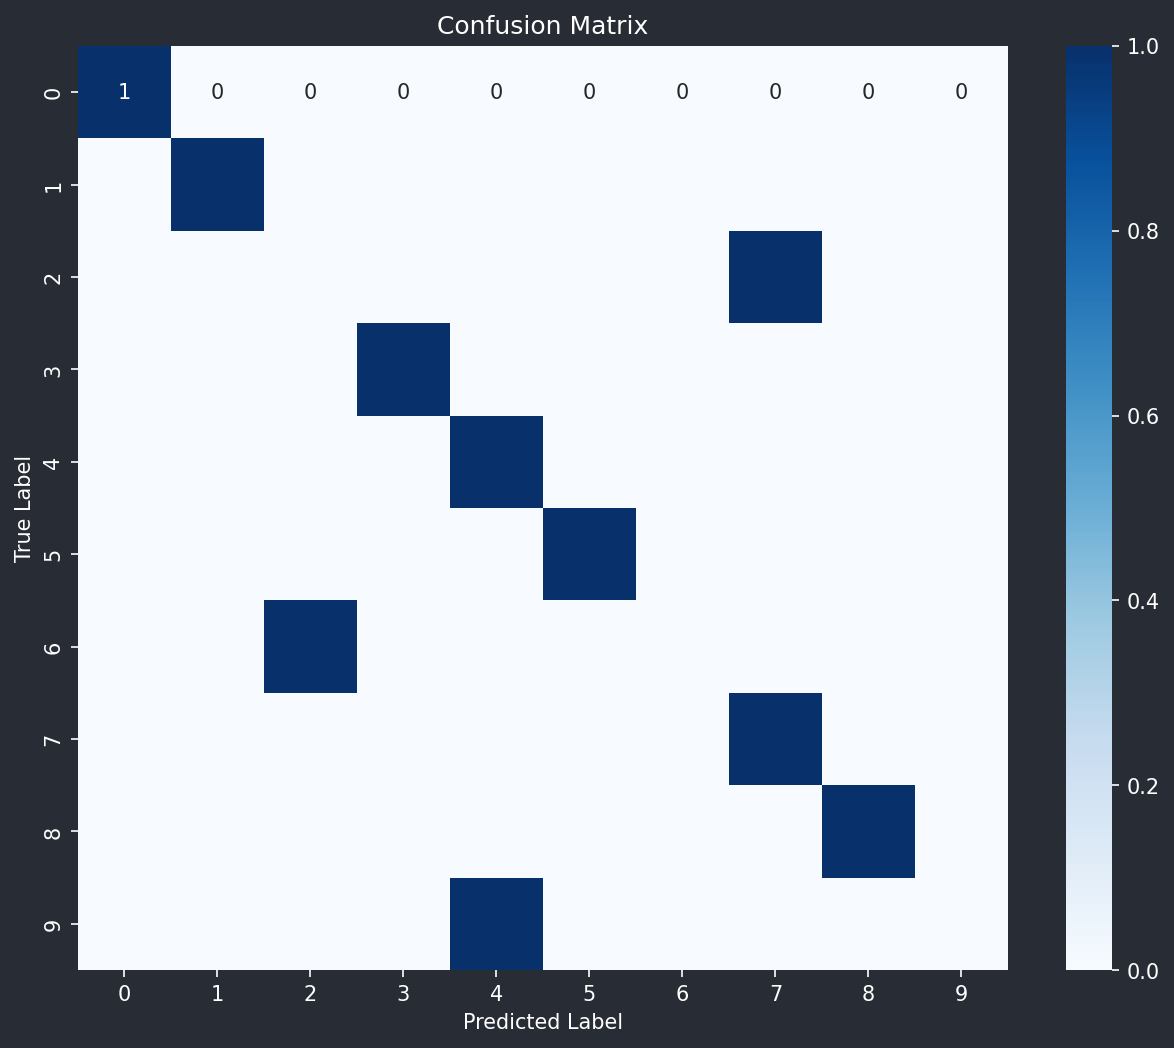

In [63]:
conf_matrix = confusion_matrix(df_predictions['True Label'], df_predictions['Predicted Label'])

plt.figure(figsize=(10, 8))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
plt.style.use('default') 

plt.rcParams.update({
    'figure.facecolor':   'white',  
    'axes.facecolor':     'white',    
    'text.color':         'black',  
    'axes.labelcolor':    'black',  
    'xtick.color':        'black',  
    'ytick.color':        'black',  
    'grid.color':         '#dddddd',    

    'figure.figsize': (16, 4),          
    'figure.dpi': 150
})

conf_matrix = confusion_matrix(df_predictions['True Label'], df_predictions['Predicted Label'])

plt.figure(figsize=(10, 8))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - Hybrid QkNN (k={k}, {number_samples} samples), Accuracy: {accuracy_score*100:.2f}%')

savefig('1. Data/3. Images/qknn_IBM_1000_confusion_matrix.png', 
        transparent=False,          
        dpi=150,
        bbox_inches='tight',
        facecolor='white',          
        edgecolor='none')

plt.show()